# ML модель CatBoost «Машина времени»
## Суть концепции

Модель пытается предсказать совершит ли клиент покупку в будущем.

Для этого мы формируем данные, используя временное окно.

1. Берём клиента.
2. Мысленно ставим его в несколько точек истории с его первой покупки до конца датасата минус 3 месяца.
3. Смотрим назад - видим последний ордер + можем сформировать обобщённые аналицы на **выбранную дату**.
4. Смотрим вперёд - видим количество дней до следующего заказа или его отсутствие (условно 10000 дней).

**У нас есть таргет - будет ли следующая покупка (можно лимитировать по интервалу)**\
**У нас есть параметры - всё что было с покупателем до даты на которую мы мысленно установили временное окно**

Собственно, а что нам ещё нужно?\
Можно сказать, что мы нарезаем историю датасета по временным слоям.

-----------------------------------------
***`Мы переносимся в прошлое, чтобы научиться предсказывать будущее.`***



In [2]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from catboost import CatBoostClassifier
from sqlalchemy import create_engine, text
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

print('Необходимые библиотеки загружены.')

Необходимые библиотеки загружены.


In [3]:
# загрузка переменных из .env
load_dotenv()

# получаем токен из окружения
POSTGRES_CONNECTION_URL = os.getenv("POSTGRES_CONNECTION_URL")

try:
    # 1. Загрузка данных
    engine = create_engine(POSTGRES_CONNECTION_URL)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # engine.dispose()
    print("Connected.")

Connected.


## Загрузка датасета из БД
Мы подготовили множество признаков на основе имеющихся в датасете данных. О каждом из них вы можете прочитать в ноутбуке соответствующего исследования. Здесь я перечислю их в общем.

Мы постарались максимально избежать "утечки данных", избегая например передавать обобщённые результаты анализов за весь временной период и по всем клиентам.

**Она не должна подглядывать будущее, пока учится**

In [95]:
customer_features = pd.read_sql_query(
  f"""SELECT
  cft.customer_unique_id,
  cft.timeline_date,
  cft.city_size,
  cft.city_center_distance_km,
  cft.city_center_level,
  cft.days_after_order,
  cft.days_before_order,
  cft.is_customer_will_order,
  cft.days_before_order < 30 as is_customer_will_month,
  cft.state_income,
--  cft.state_density,
--  cft.customer_state,
  cft.last_delivery_distance_km,
  cft.last_delivery_cost,
  cft.last_order_cost,
  cft.last_review_score,
  cft.last_review_length,
  cft.last_review_match_description,
  cft.last_review_product_state,
  cft.last_review_recommend,
  cft.last_review_sentiment,
  cft.last_review_buy_again,
  cft.last_review_want_leave,
  cft.last_review_unexpected_issues,
  cft.last_review_quality_happy,
  cft.avg_order_interval_days,
  coalesce(cft.main_payment_type, 'not_defined') as main_payment_type,
  cft.last_order_day_of_year,
  cft.previos_orders_count,
--  cft.last_delivery_actual_days,
--  cft.last_delivery_delay_days,

  srm.percent_null_reviews,
  srm.dispersion_review_score,
  srm.avg_review_message_length,
  srm.product_count,
  srm.order_date_variance,

  p.product_name_lenght,
  p.product_description_lenght,
  p.product_photos_qty
 -- p.product_weight_g,
  --p.product_length_cm,
  --p.product_height_cm,
  --p.product_width_cm


FROM customer_features_timeline cft
left join orders o on o.order_id ::uuid=cft.order_id 
inner join orders_items oi on oi.order_id =o.order_id
left join seller_retention_metrics srm on srm.seller_id =oi.seller_id
left join products p on p.product_id = oi.product_id

where cft.id is not null and cft.timeline_date<'2018-03-15'""", engine)

### Смысловое значение параметров
- `city_size` - Размер города покупателя
- `city_center_distance_km` - Удалённость покупателя от центра города
- `city_center_level` - Удалённость покупателя от центра города (относительная)
- `days_after_order` - Количество дней, прошедшее после последней покупки
- `state_income` - Средний доход по штату
- `last_delivery_distance_km` - Дальность последней доставки в километрах
- `last_delivery_cost` - Цена последней доставки
- `last_order_cost` - Цена последней покупки
- `last_review_score` - Оценка в последнем отзыве
- `last_review_length` - Длина последнего отзыва
- `last_review_product_state` - Состояние продукта по последнему отзыву (NLP анализ)
- `last_review_sentiment` - Настроение клиента по последнему отзыву (NLP анализ)
- `avg_order_interval_days` - Средний интервал между прошлыми покупками
- `main_payment_type` - Основной способ оплаты
- `last_order_day_of_year` - Номер дня в году для последнего ордера (учёт сезонности)
- `percent_null_reviews` - Доля продаж без отзыва у продавца
- `dispersion_review_score` - Дисперсия оценки отзывов продавца
- `avg_review_message_length` - Средняя длина отзывов у продавца
- `product_count` - Количество продуктов у продавца
- `order_date_variance` - Дисперсия продаж у продавца
- `product_name_lenght` - Длина названия последнего купленного продукта
- `product_description_lenght` - Длина описания последнего купленного продукта
- `product_photos_qty` - Количество фотографий у последнего купленного продукта`


## Отделение тестовых данных

Мы жёстко разделили тестовые и учебные данные по:
- `Покупатель`
- `Дата прогноза` - для обучения используются "окна" до `2018-02-01`, а для тестирования после?

Почему `2018-02-01`? Когда мы формировали обучающий датасет из окон мы уже отступили 3 месяца от границы нормальных данных и попали в `2018-05-01`. Здесь мы отступаем ещё 3 месяца на тестирование.

Идентификаторы тестовых покупателей мы стали ***выносить в отдельную таблицу***, чтобы видеть их в интерфейсе сайта. Так мы сможем наглядно сравнивать результаты предсказаний.

In [ ]:
CREATE TABLE customer_test_ids (
    id SERIAL PRIMARY KEY,
    customer_unique_id UUID NOT NULL
);

In [96]:
import numpy as np
import pandas as pd
from sqlalchemy import text

def populate_test_ids(engine):
    try:
        with engine.connect() as connection:
            # Проверяем, есть ли данные в таблице
            result = connection.execute(text("SELECT COUNT(*) FROM customer_test_ids"))
            count = result.scalar()

            if count > 0:
                print("Test IDs already exist in the database.  Loading from the table.")
                test_customer_ids_df = pd.read_sql_query("SELECT customer_unique_id FROM customer_test_ids", engine)
                test_customer_ids = test_customer_ids_df['customer_unique_id'].tolist()
            else:
                print("Generating and storing test IDs.")
                customer_unique_ids_df = pd.read_sql_query(f"""SELECT distinct cft.customer_unique_id from customer_features_timeline cft""", engine)
                np.random.seed(42)  # для воспроизводимости
                test_customer_ids = customer_unique_ids_df.sample(frac=0.1)['customer_unique_id'].tolist()

                # Записываем в базу данных
                data = [{'customer_unique_id': id} for id in test_customer_ids]
                insert_stmt = text("INSERT INTO customer_test_ids (customer_unique_id) VALUES (:customer_unique_id)")
                connection.execute(insert_stmt, data)
                connection.commit() # Важно!
                print("Test IDs generated and stored in the database.")
    except Exception as e:
        print(f"An error occurred: {e}")
        test_customer_ids = [] # Ensure test_customer_ids is defined even if there's an error
    finally:
        return test_customer_ids

# Использование:
test_customer_ids = populate_test_ids(engine)

if test_customer_ids:
    print(f"Number of test customer IDs: {len(test_customer_ids)}")
else:
    print("Failed to retrieve or generate test customer IDs.")

Test IDs already exist in the database.  Loading from the table.
Number of test customer IDs: 7143


In [97]:
# 1. Разделяем тестовые ID на валидацию и тест (20% / 80%)
val_ids = np.random.choice(test_customer_ids, 
                          size=int(len(test_customer_ids)*0.2), 
                          replace=False)
test_ids = list(set(test_customer_ids) - set(val_ids))

## Подготовка данных для обучения

- Разделяем данные на тестовые и обучающие по дате окна `timeline_date` и уникальному идентификатору покупателя `customer_unique_id`
- Учитываем дисбаланс классов (3% повторных заказов). Для этого используем балансировку весов классов `compute_sample_weight`
- Помечаем категориальные признаки
- Разделяем данные на таргет и параметры (X и y)
- Пустные значения заполняем средними значениями (надо будет их потом сохранить)

In [99]:
# Убедимся, что timeline_date — datetime
customer_features['timeline_date'] = pd.to_datetime(customer_features['timeline_date'])

# Выбираем дату-разделитель
# split_date = pd.to_datetime("2018-02-01")
# split_date = pd.to_datetime("2018-01-01")
split_date = pd.to_datetime("2017-12-15")

# Делим по дате и customer_unique_id
train_df = customer_features[
    (~customer_features['customer_unique_id'].isin(test_customer_ids)) &
    (customer_features['timeline_date'] < split_date)
]

val_df = customer_features[
    (customer_features['customer_unique_id'].isin(val_ids)) &
    (customer_features['timeline_date'] >= split_date)
]

test_df = customer_features[
    (customer_features['customer_unique_id'].isin(test_ids)) &
    (customer_features['timeline_date'] >= split_date)
]


# 3. Проверяем размеры выборок
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Unique customers - Train: {train_df['customer_unique_id'].nunique()}, "
      f"Val: {val_df['customer_unique_id'].nunique()}, "
      f"Test: {test_df['customer_unique_id'].nunique()}")

# Убираем object/string и нечисловые данные
# Список категориальных признаков, которые НЕ нужно исключать
cat_features = ['main_payment_type', 'customer_state']
cat_features = ['main_payment_type']
cols_to_exclude = [
    col for col in train_df.select_dtypes(include=['object', 'string']).columns
    if col not in cat_features
]
train_df = train_df.drop(columns=cols_to_exclude)
test_df = test_df.drop(columns=cols_to_exclude)
val_df = val_df.drop(columns=cols_to_exclude)

# X и y
drop_cols = ['is_customer_will_order', 'is_customer_will_month', 'days_before_order', 'timeline_date']
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['is_customer_will_order']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['is_customer_will_order']

X_val = val_df.drop(columns=drop_cols, errors='ignore')
y_val = val_df['is_customer_will_order']

# NaN → среднее
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_train.mean(numeric_only=True))  # подгонка под train
X_val = X_val.fillna(X_train.mean(numeric_only=True))  # подгонка под train

# Веса классов
sample_weights = compute_sample_weight('balanced', y_train)


Train: 28207, Val: 672, Test: 2891
Unique customers - Train: 15805, Val: 502, Test: 1943


## Обучаем модель
- Используем `CatBoost` для бинарной классификации.
- Использование `optuna` для подбора гиперпараметров обсуждается в отдельном ноутбуке

0:	learn: 0.6533374	test: 0.2782931	best: 0.2782931 (0)	total: 54.7ms	remaining: 1m 27s
200:	learn: 0.8622930	test: 0.3052209	best: 0.3127208 (122)	total: 8.52s	remaining: 59.3s
400:	learn: 0.9391701	test: 0.2951252	best: 0.3127208 (122)	total: 16.1s	remaining: 48.1s
600:	learn: 0.9673670	test: 0.3187500	best: 0.3347763 (498)	total: 23.7s	remaining: 39.4s
800:	learn: 0.9811369	test: 0.3030303	best: 0.3347763 (498)	total: 31.4s	remaining: 31.3s
Stopped by overfitting detector  (400 iterations wait)

bestTest = 0.3347763348
bestIteration = 498

Shrink model to first 499 iterations.
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2544
        True       0.34      0.33      0.33       347

    accuracy                           0.84      2891
   macro avg       0.62      0.62      0.62      2891
weighted avg       0.84      0.84      0.84      2891



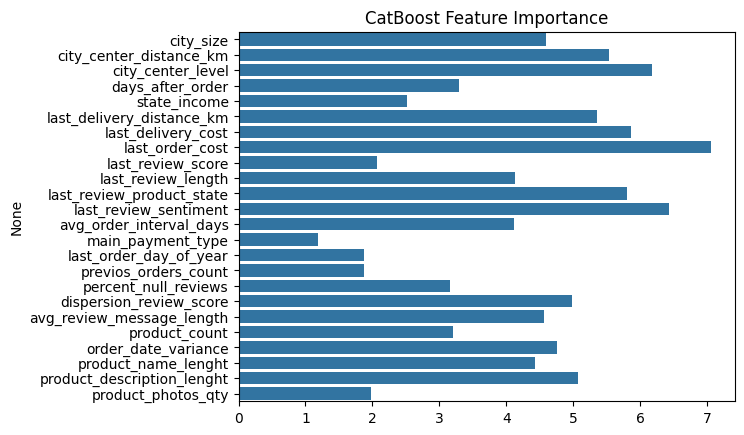

In [100]:

model = CatBoostClassifier(
    iterations=1600,
    learning_rate=0.06777903832127262,
    depth=6,
    l2_leaf_reg=9.0490576545471,
    random_strength=0.7961766953481294,
    eval_metric='F1',
    verbose=200,
    random_seed=42,
    cat_features=cat_features,
    early_stopping_rounds=400
)

model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Предсказания и отчёт
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
importances = model.get_feature_importance()
sns.barplot(x=importances, y=X_train.columns)
plt.title('CatBoost Feature Importance')
plt.show()

In [101]:
# Валидация модели
y_val_pred = model.predict(X_val)
print(classification_report(y_val, y_val_pred))


              precision    recall  f1-score   support

       False       0.97      0.90      0.93       634
        True       0.22      0.47      0.30        38

    accuracy                           0.88       672
   macro avg       0.59      0.69      0.62       672
weighted avg       0.92      0.88      0.90       672



### Значимость признаков

In [35]:
importances = model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({
    'feature': features,
    'importance_%': (importances / importances.sum()) * 100
}).sort_values(by='importance_%', ascending=False)

print(importance_df.to_string(index=False, float_format='%.2f'))

                   feature  importance_%
           last_order_cost          6.58
        last_delivery_cost          6.54
         city_center_level          6.20
product_description_lenght          5.68
 last_delivery_distance_km          5.57
   city_center_distance_km          5.44
                 city_size          5.38
       product_name_lenght          5.17
       order_date_variance          5.00
 avg_review_message_length          4.83
   dispersion_review_score          4.83
      percent_null_reviews          4.42
             product_count          4.22
        last_review_length          3.92
     last_review_sentiment          3.43
   avg_order_interval_days          3.27
         last_review_score          3.14
              state_income          3.13
 last_review_product_state          2.99
        product_photos_qty          2.93
          days_after_order          2.90
    last_order_day_of_year          2.75
         main_payment_type          1.68


### Сохраняем модель для дельнейшего использования

Для дальнейшего использования необходимо предпринять ряд мер:
- Нам понадобится сам файл модели
- Средние значения, которыми мы заполняни пропуски, нужны те же самые, с которыми училась модель. Сохраним их в БД
- Названия колонок по которым училась модель. Чтобы было проще формировать датасет для предсказания

In [102]:
model.save_model("ml-models/TimeMachine pure-base 1.1.cbm")

In [68]:
# Записать средние значения в БД
import json
numeric_means = X_train.mean(numeric_only=True)
mean_values_json = json.dumps(numeric_means.to_dict())
print(mean_values_json)

{"city_size": 20.882700359865833, "city_center_distance_km": 9.17670948744489, "city_center_level": 41.7587261918098, "days_after_order": 82.18721711372623, "state_income": 2347.2184001143455, "last_delivery_distance_km": 614.6204510711316, "last_delivery_cost": 51.25516175139358, "last_order_cost": 295.23598837486304, "last_review_score": 4.127219432498018, "last_review_length": 28.736575286514018, "last_review_product_state": 0.2802401553946671, "last_review_sentiment": 0.17229533456263102, "avg_order_interval_days": 8.727214255085997, "last_order_day_of_year": 210.75982657582543, "percent_null_reviews": 0.9518302444137405, "dispersion_review_score": 1.828807895871252, "avg_review_message_length": 29.43416885035018, "product_count": 78.86562008671208, "order_date_variance": 16239.230238325994, "product_name_lenght": 48.5632200635475, "product_description_lenght": 765.3983603774043, "product_photos_qty": 2.1746586140823205}


In [70]:
print(','.join(X_train.columns.tolist()))

city_size,city_center_distance_km,city_center_level,days_after_order,state_income,last_delivery_distance_km,last_delivery_cost,last_order_cost,last_review_score,last_review_length,last_review_product_state,last_review_sentiment,avg_order_interval_days,main_payment_type,last_order_day_of_year,percent_null_reviews,dispersion_review_score,avg_review_message_length,product_count,order_date_variance,product_name_lenght,product_description_lenght,product_photos_qty


## Пример последующей загрузки и использования модели

Собственно попробуем использовать модель так, как будем использовать её в будущем.\
Вызов предсказания модели помещён в `api-метод`, хоть данные статичны и можно было заполнить всё заранее, мы решили, что `модель должна работать на живую`.

In [57]:
MODEL_WORK_FILENAME = "TimeMachine pure-base 1.1.cbm"

In [55]:

model = CatBoostClassifier()
model.load_model(f"ml-models/{MODEL_WORK_FILENAME}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.96      0.99      0.97      5773
        True       0.38      0.17      0.23       277

    accuracy                           0.95      6050
   macro avg       0.67      0.58      0.60      6050
weighted avg       0.93      0.95      0.94      6050



In [71]:
# Информация о модели из БД

about_model_record = pd.read_sql_query(f"SELECT * FROM api_mlmodel where model_file='{MODEL_WORK_FILENAME}'", engine).to_dict('records')[0]
about_model_mean_values = about_model_record['mean_values_json']

In [9]:
# sample = X_test.sample(1, random_state=42)
sample = X_test.sample(1)

pred_class = model.predict(sample)[0]
pred_proba = model.predict_proba(sample)[0][1]  # вероятность класса True

print("Класс:", bool(pred_class))
print("Вероятность повторной покупки:", f'{(100 * pred_proba):.2f}%')

Класс: False
Вероятность повторной покупки: 1.18%


### Получить топ факторов, повлиявших на это решение (персонализированное объяснение)
Используем PredictionValuesChange + get_feature_importance(prettified=True):

In [10]:
import json
from catboost import Pool

sample_pool = Pool(sample, cat_features=cat_features)

# Получаем SHAP-значения (последний столбец — это base value)
shap_values = model.get_feature_importance(
    type='ShapValues',
    data=sample_pool
)

# Берём первую (и единственную) строку и убираем base value
shap_importances = pd.Series(shap_values[0][:-1], index=sample.columns)
shap_importances = shap_importances.abs().sort_values(ascending=False)


top_10_shap = shap_importances.head(10)

print(top_10_shap.head(10))

top_10_json = json.dumps(top_10_shap.to_dict())

print(top_10_json)

days_after_order             0.787565
last_order_day_of_year       0.434380
last_delivery_distance_km    0.359772
last_review_sentiment        0.328968
last_review_product_state    0.309139
city_size                    0.294211
city_center_distance_km      0.284306
product_count                0.254403
percent_null_reviews         0.234411
product_name_lenght          0.209918
dtype: float64
{"days_after_order": 0.7875649407729692, "last_order_day_of_year": 0.43438001809623333, "last_delivery_distance_km": 0.35977196913381176, "last_review_sentiment": 0.3289683467205843, "last_review_product_state": 0.3091389892061013, "city_size": 0.29421116761241706, "city_center_distance_km": 0.284306060906528, "product_count": 0.25440349777381627, "percent_null_reviews": 0.23441062837371282, "product_name_lenght": 0.2099177435155125}


### Прогнозируем актуальную дату 1.08.2018

Теперь нужно всем клиентам проставить актуальный прогноз, чтобы можно было их фильтровать.\
Для отдельных клиентов мы будем делать каждый раз новое предсказание.

In [73]:
customer_features_current = pd.read_sql_query(
  f"""
SELECT
  ctf.id as ctf_id,
  cft.*,
  cft.days_before_order < 30 as is_customer_will_month,
  srm.*,
  p.*
FROM customer_features_current cft
left join orders o on o.order_id ::uuid=cft.order_id 
inner join orders_items oi on oi.order_id =o.order_id
left join seller_retention_metrics srm on srm.seller_id =oi.seller_id
left join products p on p.product_id =oi.product_id
left join product_retention_metrics prm on prm.product_id =oi.product_id
where cft.id is not null""", engine)

customer_features_current_ids = customer_features_current['ctf_id']
customer_features_current['main_payment_type'] = customer_features_current['main_payment_type'].fillna('not_defined')
customer_features_current['timeline_date'] = pd.to_datetime(customer_features_current['timeline_date'])
X_production = customer_features_current[about_model_record['feature_columns']]
# NaN → среднее
X_production = X_production.fillna(value=about_model_record['mean_values_json'])

X_production

,city_size,city_center_distance_km,city_center_level,days_after_order,state_income,last_delivery_distance_km,last_delivery_cost,last_order_cost,last_review_score,last_review_length,...,main_payment_type,last_order_day_of_year,percent_null_reviews,dispersion_review_score,avg_review_message_length,product_count,order_date_variance,product_name_lenght,product_description_lenght,product_photos_qty
0,44.354600,11.762632,0.265195,214,2490.0,664.065730,35.20,99.80,1.0,85.0,...,credit_card,213,0.41,2.1002,37.19,23,10762.853772,59.0,341.0,2.0
1,14.941645,0.344270,0.023041,199,2001.0,313.503330,35.74,398.00,5.0,91.0,...,credit_card,213,0.00,1.7198,59.07,9,5853.478022,59.0,695.0,2.0
2,11.364401,1.260987,0.110959,443,2001.0,162.378620,25.38,43.80,4.0,0.0,...,boleto,213,0.00,1.1502,26.17,9,1923.055336,36.0,558.0,1.0
3,38.673510,16.105257,0.416442,435,2662.0,48.684834,28.54,1558.00,5.0,0.0,...,credit_card,213,0.29,1.6673,28.52,186,13893.583550,32.0,352.0,1.0
4,26.306171,13.235710,0.503141,379,2098.0,461.285830,35.34,119.80,5.0,0.0,...,credit_card,213,0.41,2.1002,37.19,23,10762.853772,57.0,366.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101735,5.345493,0.224674,0.042031,257,2001.0,340.690800,42.28,186.98,4.0,0.0,...,boleto,213,0.53,1.7079,27.01,133,19656.144826,56.0,2079.0,1.0
101736,13.254108,1.722081,0.129928,161,2662.0,774.053200,51.76,298.00,5.0,0.0,...,credit_card,213,2.22,2.3209,40.88,39,33573.431533,59.0,3314.0,2.0
101737,4.564488,0.653408,0.143150,99,2662.0,31.360506,22.30,109.80,2.0,0.0,...,credit_card,213,0.78,1.9144,22.77,23,27924.928150,44.0,1313.0,4.0
101738,18.798883,1.571303,0.083585,84,2662.0,339.589870,20.58,115.78,1.0,0.0,...,boleto,213,1.16,1.2232,16.94,22,1123.179207,36.0,890.0,1.0


In [74]:
# Проверяем что колонках нет None/NaN
null_columns = X_production.columns[X_production.isnull().any()]
print("Колонки с None/NaN:", null_columns.tolist())

Колонки с None/NaN: []


In [75]:
# Предсказываем.
Y_production_proba = model.predict_proba(X_production)[:, 1]

### Обновляем предсказания в БД

In [78]:
# 1. Подготовка данных с группировкой по ID (берем среднее значение для дубликатов)
update_data = pd.DataFrame({
    'id': customer_features_current_ids,
    'pred_proba': Y_production_proba
}).groupby('id')['pred_proba'].mean().reset_index()

# Выполняем массовое обновление
with engine.begin() as conn:

    # Создаём временную таблицу
    update_data.to_sql('temp_update_table', engine, if_exists='replace', index=False)

    conn.execute(text("""
        UPDATE customer_features_current cfc
        SET pred_proba = temp.pred_proba
        FROM temp_update_table temp
        WHERE cfc.id = temp.id
    """))
    
    # Удаляем временную таблицу
    conn.execute(text("DROP TABLE temp_update_table"))

In [45]:
update_data

,id,pred_proba
0,26235,0.107015
1,6870,0.017817
2,74185,0.007318
3,34638,0.009099
4,10001,0.016634
...,...,...
101735,43107,0.039512
101736,1921,0.024091
101737,62013,0.009836
101738,78848,0.010979


## Итоги.
У нас получилась модель, обладающая не очень высокой точностью (23% F1). Однако, учитывая очень большой дисбаланс по одиночным покупкам мы считаем это значимым результатом. Тем более, что, как вы в дальнейшем увидите, благодаря балансировке порога между Recall и Precision можно получать `ситуативно более значимые параметры модели`, используя ту же модель.